# Propensity Score & Matching
Después de haber definido los features tanto para unidades de control como para tratamiento es momento de hacer el propensity score y balancear los dos grupos antes de pasar a hacer el DiD. 

In [1]:
from nbsetup import *
from pipeline import Datos, UnidadesTratadas, UnidadesControl, Features, COVARIABLES

datos = Datos()
tratadas = UnidadesTratadas(datos, radio_m=300)
control = UnidadesControl(datos, tratadas, semilla=0)

features = Features(datos, tratadas, control)

In [2]:
# Para el propensity score se utilizan estas variables
X = features.matriz[COVARIABLES] # las variables que se usan
Z = (X - X.mean()) / X.std()
y = features.matriz.tratado      # lo que se quiere predecir

## El modelo

Regresión logística sobre las covariables estandarizadas. Tres decisiones que
no son el default de sklearn:

**Sin penalización (`C=np.inf`).** El propensity score no busca predecir bien
fuera de muestra, busca balancear covariables *en esta muestra*. Regularizar
encoge coeficientes y con eso deja desbalance que precisamente se quería
corregir. El default de sklearn aplica L2 con `C=1.0`.

**Covariables estandarizadas.** Con las variables en su escala original el solver
no converge ni con 100,000 iteraciones: `afluencia_nivel` llega a 10 millones
mientras `pct_lesionados` vive entre 0 y 1. Estandarizar no cambia el modelo —la
logística es equivariante a reescalamientos— pero permite que el solver llegue
al máximo.

**Tolerancia estricta (`tol=1e-10`).** Estandarizadas, las variables ya convergen
con el solver por defecto, pero este se detiene en cuanto alcanza su tolerancia
(`1e-4`), antes de llegar al máximo. El error que deja en el logit llega a 0.54,
casi tres veces el ancho del caliper, y alcanza para cambiar hasta 18 de 99 pares: era
la tolerancia del solver, no los datos, la que decidía quién se emparejaba con
quién. Con `tol=1e-10` el error baja a 0.01 y los pares coinciden, en los cinco
radios, con los de un método de Newton. La comprobación está más abajo, después
de la muestra común.

In [3]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(C=np.inf, tol=1e-10, max_iter=100_000).fit(Z, y)

ps = pd.Series(modelo.predict_proba(Z)[:, 1], index=Z.index, name="ps")
datos_ps = features.matriz.assign(ps=ps)

print(f"convergió en {np.atleast_1d(modelo.n_iter_)[0]} iteraciones")
print(f"tratadas: {y.sum()} de {len(y):,}  ({y.mean():.2%} de la muestra)")
print()
print("propensity score por grupo:")
print(datos_ps.groupby("tratado").ps.describe().round(4).to_string())

convergió en 29 iteraciones
tratadas: 99 de 14,755  (0.67% de la muestra)

propensity score por grupo:
           count    mean     std    min     25%     50%     75%     max
tratado                                                                
0        14656.0  0.0066  0.0081  0.000  0.0021  0.0039  0.0080  0.1393
1           99.0  0.0182  0.0232  0.001  0.0054  0.0107  0.0191  0.1400


### Comprobación: ¿y si no estandarizamos?

En teoría la escala no debería importar. Multiplicar una variable por mil divide
su coeficiente entre mil y las probabilidades predichas quedan idénticas: la
regresión logística es equivariante a reescalamientos lineales.

La comprobación de abajo muestra que eso es cierto **solo si el solver
converge**, y que con los defaults de sklearn no converge. Por eso el código de
arriba especifica `C` y `tol` en vez de confiar en ellos.

In [4]:
# A) mismo solver, mismas condiciones: el PS no cambia
modelo_crudo = LogisticRegression(max_iter=5000, C=np.inf, solver="newton-cholesky").fit(X, y)
ps_crudo = modelo_crudo.predict_proba(X)[:, 1]

print("A) newton-cholesky, C=inf, sobre X sin estandarizar")
print(f"   correlación con el PS del modelo estandarizado: {np.corrcoef(ps, ps_crudo)[0, 1]:.8f}")
print(f"   diferencia máxima: {np.abs(ps - ps_crudo).max():.6f}")
print()
print("   los coeficientes SÍ se ven distintos, pero es solo un cambio de unidades:")

comparacion = pd.DataFrame({
    "coef_sobre_Z": modelo.coef_[0],
    "coef_sobre_X": modelo_crudo.coef_[0],
    "sd_de_X": X.std().values,
}, index=COVARIABLES)
comparacion["coef_X_por_sd"] = comparacion.coef_sobre_X * comparacion.sd_de_X
comparacion.round(6)

A) newton-cholesky, C=inf, sobre X sin estandarizar
   correlación con el PS del modelo estandarizado: 1.00000000
   diferencia máxima: 0.000000

   los coeficientes SÍ se ven distintos, pero es solo un cambio de unidades:


,coef_sobre_Z,coef_sobre_X,sd_de_X,coef_X_por_sd
road_length_m,0.278377,0.000209,1329.486415,0.278377
n_vialidades,-0.154756,-0.157574,0.982113,-0.154755
carriles_ponderados,0.433506,0.713092,0.607924,0.433506
pct_acceso_controlado,-0.001354,-0.003478,0.389192,-0.001354
pct_doble_sentido,0.141852,0.749833,0.189179,0.141853
pct_desnivel,-0.587689,-3.839970,0.153045,-0.587689
n_niveles,0.364838,0.538311,0.677745,0.364837
nivel_incidentes,0.422289,0.138994,3.038173,0.422289
pct_lesionados,0.015922,0.157956,0.100798,0.015922
tendencia,0.190531,0.156196,1.219823,0.190531


In [5]:
# B) el solver por defecto de sklearn no converge con las variables crudas
lbfgs_z = LogisticRegression(max_iter=5000, C=np.inf).fit(Z, y)
lbfgs_x = LogisticRegression(max_iter=5000, C=np.inf).fit(X, y)

# C) y por defecto sklearn además penaliza, lo que sí cambia el modelo
default_x = LogisticRegression(max_iter=5000).fit(X, y)

print(f"B) lbfgs (default), C=inf")
print(f"   iteraciones sobre Z: {np.atleast_1d(lbfgs_z.n_iter_)[0]:>4}"
      f"   |   sobre X: {np.atleast_1d(lbfgs_x.n_iter_)[0]:>4}")
print(f"   correlación con el PS correcto — sobre Z: "
      f"{np.corrcoef(ps, lbfgs_z.predict_proba(Z)[:, 1])[0, 1]:.4f}"
      f"   |   sobre X: {np.corrcoef(ps, lbfgs_x.predict_proba(X)[:, 1])[0, 1]:.4f}")
print()
print(f"C) todo por default (lbfgs + penalización L2), sobre X")
print(f"   correlación con el PS correcto: "
      f"{np.corrcoef(ps, default_x.predict_proba(X)[:, 1])[0, 1]:.4f}")
print()

# lo que importa no es la correlación sino a quién emparejarías
top_correcto = set(ps[y == 1].nlargest(20).index)
for etiqueta, vector in [
    ("lbfgs sobre X", lbfgs_x.predict_proba(X)[:, 1]),
    ("default sobre X", default_x.predict_proba(X)[:, 1]),
]:
    serie = pd.Series(vector, index=X.index)
    top = set(serie[y == 1].nlargest(20).index)
    print(f"   {etiqueta:<18}: de las 20 tratadas con mayor PS, "
          f"coinciden {len(top_correcto & top)} de 20")

B) lbfgs (default), C=inf
   iteraciones sobre Z:   15   |   sobre X:  292
   correlación con el PS correcto — sobre Z: 0.9998   |   sobre X: 0.3770

C) todo por default (lbfgs + penalización L2), sobre X
   correlación con el PS correcto: 0.1436

   lbfgs sobre X     : de las 20 tratadas con mayor PS, coinciden 5 de 20
   default sobre X   : de las 20 tratadas con mayor PS, coinciden 6 de 20


**Qué deja esto.** Con el solver adecuado, estandarizar no cambia el modelo:
cambia las unidades en que se leen los coeficientes, y solo en las estandarizadas
son comparables entre sí. Sobre las variables crudas, `pct_desnivel` parece la
más influyente del modelo con un coeficiente de -3.84 y `afluencia_nivel` parece
irrelevante con 0.0000001; las dos lecturas son artefactos de las unidades.
Multiplicar cada coeficiente crudo por la desviación estándar de su variable
recupera exactamente el estandarizado.

Con los defaults de sklearn el modelo **corre, devuelve probabilidades entre 0 y
1, y no advierte nada** — pero tres cuartas partes del ranking de tratadas
cambian, y con eso cambia cada pareja y el efecto estimado. No es un error que se
detecte mirando los resultados.

In [6]:
# los coeficientes, en odds ratio: cuánto multiplica los odds de recibir cámara
# una desviación estándar más de cada covariable
coeficientes = (
    pd.DataFrame({
        "coef": modelo.coef_[0],
        "odds_ratio": np.exp(modelo.coef_[0]),
    }, index=COVARIABLES)
    .sort_values("odds_ratio", ascending=False)
)
coeficientes.round(3)

,coef,odds_ratio
hubo_fcs,0.440,1.553
carriles_ponderados,0.434,1.543
nivel_incidentes,0.422,1.525
n_niveles,0.365,1.440
road_length_m,0.278,1.321
tendencia,0.191,1.210
pct_doble_sentido,0.142,1.152
afluencia_nivel,0.060,1.061
pct_lesionados,0.016,1.016
pct_acceso_controlado,-0.001,0.999


## Soporte común

El emparejamiento solo tiene sentido donde las dos distribuciones se traslapan.
Una tratada con un propensity score que ningún control alcanza no tiene
contrafactual: emparejarla es extrapolar.

In [7]:
tratadas_ps = datos_ps.loc[datos_ps.tratado == 1, "ps"]
controles_ps = datos_ps.loc[datos_ps.tratado == 0, "ps"]

print(f"{'':<12} {'mínimo':>10} {'mediana':>10} {'máximo':>10}")
for nombre, serie in [("tratadas", tratadas_ps), ("controles", controles_ps)]:
    print(f"{nombre:<12} {serie.min():>10.4f} {serie.median():>10.4f} {serie.max():>10.4f}")
print()

fuera_arriba = (tratadas_ps > controles_ps.max()).sum()
fuera_abajo = (tratadas_ps < controles_ps.min()).sum()
print(f"tratadas por encima del control más alto: {fuera_arriba}")
print(f"tratadas por debajo del control más bajo: {fuera_abajo}")
print()

# controles disponibles en el rango de cada tratada, por decil de propensity score
decil = pd.qcut(tratadas_ps, 5, labels=["muy bajo", "bajo", "medio", "alto", "muy alto"])
for etiqueta, grupo in tratadas_ps.groupby(decil, observed=True):
    disponibles = controles_ps.between(grupo.min(), grupo.max()).sum()
    print(f"  PS {etiqueta:<9} [{grupo.min():.4f}, {grupo.max():.4f}]: "
          f"{len(grupo):>2} tratadas, {disponibles:>6,} controles en ese rango")

                 mínimo    mediana     máximo
tratadas         0.0010     0.0107     0.1400
controles        0.0000     0.0039     0.1393

tratadas por encima del control más alto: 1
tratadas por debajo del control más bajo: 0



  PS muy bajo  [0.0010, 0.0045]: 20 tratadas,  7,196 controles en ese rango
  PS bajo      [0.0048, 0.0088]: 20 tratadas,  2,936 controles en ese rango
  PS medio     [0.0088, 0.0139]: 19 tratadas,  1,591 controles en ese rango
  PS alto      [0.0146, 0.0208]: 20 tratadas,    686 controles en ese rango
  PS muy alto  [0.0218, 0.1400]: 20 tratadas,    740 controles en ese rango


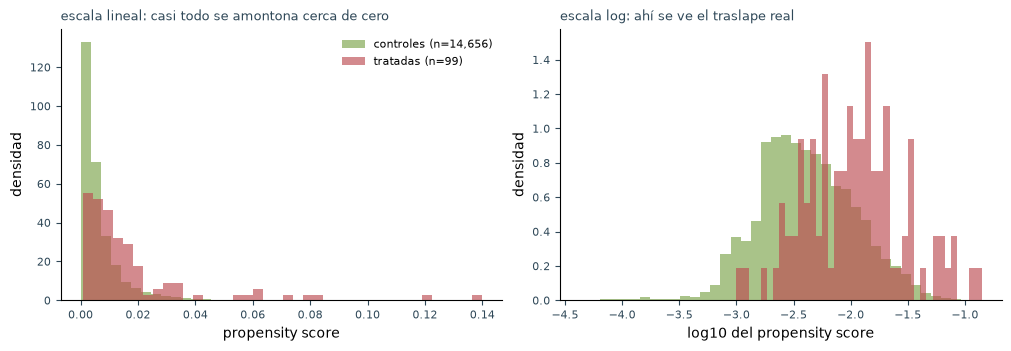

In [8]:
# cómo se traslapan las dos distribuciones
TRATADA, CONTROL, TINTA = "#BC4B51", "#7BA34A", "#2F4858"

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), layout="constrained")

for ax, escala in zip(axes, ["lineal", "log"]):
    for serie, color, etiqueta in [
        (controles_ps, CONTROL, f"controles (n={len(controles_ps):,})"),
        (tratadas_ps, TRATADA, f"tratadas (n={len(tratadas_ps)})"),
    ]:
        valores = np.log10(serie) if escala == "log" else serie
        ax.hist(valores, bins=40, density=True, alpha=.65, color=color, label=etiqueta)
    ax.set_ylabel("densidad")
    ax.set_xlabel("propensity score" if escala == "lineal" else "log10 del propensity score")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=TINTA, labelsize=8)

axes[0].set_title("escala lineal: casi todo se amontona cerca de cero", fontsize=9, loc="left", color=TINTA)
axes[1].set_title("escala log: ahí se ve el traslape real", fontsize=9, loc="left", color=TINTA)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

# Emparejamiento

Vecino más cercano 1:1 **sin reemplazo**, como pidió Alberto. Tres reglas más:

**Caliper de 0.2 desviaciones estándar del logit del propensity score.** Es el
valor estándar en la literatura de matching. Una tratada que no encuentra
control dentro de esa distancia se queda sin pareja en vez de emparejarse con
cualquiera: perder una observación es preferible a meter una comparación falsa.

**Desempate por distancia de Mahalanobis.** Dentro del caliper suele haber
cientos de controles con propensity score casi idéntico — la distancia mediana
es de 0.0002. Elegir entre ellos por PS es elegir al azar; elegir por Mahalanobis
sobre las covariables aprovecha esa holgura para mejorar el balance. Baja el
|SMD| medio de 0.093 a 0.070 sin perder ningún par.

**600 m entre controles emparejados.** Es la restricción que quedó pendiente al
construir el pool: dos controles que se traslapan comparten incidentes y no son
observaciones independientes. Se aplica aquí, sobre los seleccionados, no sobre
el pool completo.

El orden de emparejamiento es de mayor a menor propensity score: las tratadas
más difíciles de emparejar eligen primero, cuando queda más pool disponible.

In [9]:
from scipy.spatial import cKDTree

CALIPER_SD = 0.2
SEPARACION_CONTROLES = 2 * tratadas.radio_m

# coordenadas de cada centro, para la restricción de separación
centros = pd.concat([
    tratadas.centros.assign(uid="T" + tratadas.centros.unidad_id.astype(str)),
    control.centros.assign(uid="C" + control.centros.unidad_id.astype(str)),
]).set_index("uid")

datos_ps = datos_ps.assign(
    logit_ps=lambda d: np.log(d.ps / (1 - d.ps)),
    x=centros.geometry.x,
    y=centros.geometry.y,
)

# inversa de la covarianza, para Mahalanobis sobre las covariables estandarizadas
inv_cov = np.linalg.pinv(np.cov(Z.to_numpy().T))


def emparejar(datos_ps, caliper_sd=CALIPER_SD, separacion_m=SEPARACION_CONTROLES):
    """Vecino más cercano 1:1 sin reemplazo, con caliper y separación espacial."""
    caliper = caliper_sd * datos_ps.logit_ps.std()

    t = datos_ps[datos_ps.tratado == 1].sort_values("ps", ascending=False)
    c = datos_ps[datos_ps.tratado == 0]
    c_xy, c_logit, c_id = c[["x", "y"]].to_numpy(), c.logit_ps.to_numpy(), c.index.to_numpy()
    c_z = Z.loc[c.index].to_numpy()

    disponible = np.ones(len(c), dtype=bool)
    ocupados, pares, sin_pareja = [], [], []

    for uid, fila in t.iterrows():
        distancia_ps = np.abs(c_logit - fila.logit_ps)
        elegibles = disponible & (distancia_ps <= caliper)
        if ocupados:  # ningún control puede quedar a menos de dos radios de otro ya elegido
            elegibles &= cKDTree(np.array(ocupados)).query(c_xy)[0] >= separacion_m

        if not elegibles.any():
            sin_pareja.append(uid)
            continue

        indices = np.where(elegibles)[0]
        diferencia = c_z[indices] - Z.loc[uid].to_numpy()
        mahalanobis = np.einsum("ij,jk,ik->i", diferencia, inv_cov, diferencia)
        elegido = indices[np.argmin(mahalanobis)]

        pares.append({
            "tratada": uid, "control": c_id[elegido],
            "dist_ps": distancia_ps[elegido], "dist_mahalanobis": np.sqrt(mahalanobis.min()),
        })
        ocupados.append(c_xy[elegido])
        disponible[elegido] = False

    return pd.DataFrame(pares), sin_pareja


pares, sin_pareja = emparejar(datos_ps)
emparejados = datos_ps.loc[list(pares.tratada) + list(pares.control)]

print(f"pares formados      : {len(pares)} de {int(y.sum())} tratadas")
print(f"sin pareja          : {len(sin_pareja)}  {sin_pareja}")
print(f"distancia en PS     : mediana {pares.dist_ps.median():.5f} | máxima {pares.dist_ps.max():.5f}")
print(f"caliper             : {CALIPER_SD * datos_ps.logit_ps.std():.4f}")

pares formados      : 98 de 99 tratadas
sin pareja          : 1  ['T60']
distancia en PS     : mediana 0.11599 | máxima 0.19604
caliper             : 0.1968


In [10]:
# balance antes y después del emparejamiento libre
# (la tabla que va a la tesis es la de la muestra común, más abajo)
def smd(df, covariables=COVARIABLES):
    """Diferencia de medias estandarizada por la desviación combinada."""
    t, c = df[df.tratado == 1], df[df.tratado == 0]
    return pd.Series({
        v: (t[v].mean() - c[v].mean()) / np.sqrt((t[v].var() + c[v].var()) / 2)
        for v in covariables
    })


balance = pd.DataFrame({
    "media_tratadas": emparejados[emparejados.tratado == 1][COVARIABLES].mean(),
    "media_controles": emparejados[emparejados.tratado == 0][COVARIABLES].mean(),
    "smd_antes": smd(datos_ps),
    "smd_despues": smd(emparejados),
})
balance["mejora"] = balance.smd_antes.abs() - balance.smd_despues.abs()

print(f"|SMD| medio        : {balance.smd_antes.abs().mean():.3f} -> {balance.smd_despues.abs().mean():.3f}")
print(f"|SMD| máximo       : {balance.smd_antes.abs().max():.3f} -> {balance.smd_despues.abs().max():.3f}")
print(f"variables sobre 0.1: {(balance.smd_antes.abs() > .1).sum()} -> {(balance.smd_despues.abs() > .1).sum()}")
balance.sort_values("smd_antes", key=abs, ascending=False).round(3)

|SMD| medio        : 0.266 -> 0.070
|SMD| máximo       : 0.647 -> 0.155
variables sobre 0.1: 10 -> 4


,media_tratadas,media_controles,smd_antes,smd_despues,mejora
hubo_fcs,0.714,0.735,0.647,-0.045,0.601
nivel_incidentes,6.671,6.321,0.634,0.104,0.530
carriles_ponderados,3.060,3.064,0.495,-0.005,0.490
afluencia_nivel,265535.959,191601.168,0.322,0.155,0.166
road_length_m,2746.644,2575.738,0.238,0.130,0.108
n_vialidades,2.173,2.092,0.196,0.083,0.113
pct_doble_sentido,0.104,0.102,0.179,0.009,0.170
tendencia,0.116,0.190,0.168,-0.055,0.112
pct_acceso_controlado,0.360,0.369,0.161,-0.024,0.137
n_niveles,1.612,1.571,0.128,0.052,0.075


# La muestra que se reporta

Todo lo de arriba corre a 300 m sobre la **muestra máxima**: 98 pares de las 99
unidades tratadas que define `unit-design`. Esa no es la muestra que va a la
tesis, y conviene dejar por qué.

El radio de 300 m es el que sostiene la tesis; los otros cuatro son robustez. Y
robustez quiere decir *el coeficiente no se mueve cuando cambio el radio*. Eso
solo se puede afirmar si la muestra tratada es idéntica en las cinco corridas, y
no lo es: cuáles unidades encuentran control dentro del caliper depende del
radio, porque las covariables se miden dentro del círculo.

| Radio | Pares | Sin pareja |
| --- | --- | --- |
| 100 m | 96 | 3 |
| 150 m | 98 | 1 |
| 200 m | 99 | 0 |
| 250 m | 97 | 2 |
| 300 m | 98 | 1 |

Con estas muestras, un coeficiente que cambia entre 100 y 200 m no distingue el
radio de la composición. Y las tres unidades que entran a 200 m no son un
descarte aleatorio: son justo las de los extremos del propensity score, las más
raras.

**Se reporta la intersección: 93 unidades tratadas, en los cinco radios.**

Lo que sí se rehace en cada radio es el emparejamiento. Reusar los pares del
radio mayor en el menor dispara el |SMD| de 0.07 a 0.21, porque un control que
se parecía a su tratada a 300 m no tiene por qué parecérsele a 100. Los
controles son el instrumento para estimar el contrafactual y tienen que ser
comparables *a cada escala*; lo que define el estimando es la muestra tratada, y
esa queda fija. De eso se encarga `muestra_comun`.

**Cómo se declara en el texto.** El estimando no es "el efecto de las
Fotocívicas" a secas: es el ATT sobre las 93 unidades tratadas con soporte común
en las cinco escalas. Fijar la muestra cuesta balance en algunos radios —a 200 m
el |SMD| máximo pasa de 0.180 con muestra libre a 0.268 con la común— y ese es
el precio de poder comparar las columnas entre sí.


In [11]:
# los cinco radios sobre la muestra común
from pipeline import muestra_comun

RADIO_TESIS = 300
emparejamientos, comunes = muestra_comun(datos)

# cuántas tratadas empareja cada radio por su cuenta, antes de fijar la muestra
atricion = []
for radio, e in emparejamientos.items():
    e.pares  # materializa el emparejamiento y con él sus descartes
    fuera = e.descartes.get("fuera de la muestra común entre radios", 0)
    atricion.append({
        "radio_m": radio,
        "tratadas": len(e.features.tratadas.unidades),
        "pares_libres": len(e.pares) + fuera,
        "sin_pareja": len(e.sin_pareja),
        "pares_reportados": len(e.pares),
    })

print(f"tratadas comunes a los {len(emparejamientos)} radios: {len(comunes)}")
print()
print(pd.DataFrame(atricion).to_string(index=False))
print()
pd.DataFrame([e.diagnostico() for e in emparejamientos.values()]).round(3)

tratadas comunes a los 5 radios: 93

 radio_m  tratadas  pares_libres  sin_pareja  pares_reportados
     100        99            96           3                93
     150        99            98           1                93
     200        99            99           0                93
     250        99            97           2                93
     300        99            98           1                93



,radio_m,pares,sin_pareja,smd_medio_antes,smd_medio_despues,smd_max_despues,sobre_0.1
0,100,93,3,0.273,0.055,0.184,2
1,150,93,1,0.269,0.045,0.174,1
2,200,93,0,0.251,0.052,0.268,1
3,250,93,2,0.272,0.050,0.118,1
4,300,93,1,0.266,0.065,0.141,3


## Comprobación: ¿el solver decide los pares?

Con las covariables estandarizadas, el solver por defecto de sklearn converge en
13 a 15 iteraciones y su score correlaciona 0.999 con el de un método de Newton.
Suena a idéntico. No lo es para el emparejamiento.

La razón es de escala. El caliper mide 0.2 desviaciones estándar del logit, unos
0.2. El solver por defecto se detiene en una tolerancia de `1e-4`, y el error que
eso deja en el logit **llega a 0.54**: casi tres veces el ancho del caliper. Alcanza
para meter o sacar controles del caliper de una tratada, y como el emparejamiento
es voraz, un cambio temprano se propaga a los siguientes.

La celda compara, en los cinco radios, el emparejamiento del pipeline
(`tol=1e-10`) contra el del solver por defecto y contra `newton-cholesky`, que era
la elección anterior.


In [12]:
# el emparejamiento libre de cada radio con tres modelos distintos
from functools import cached_property
from pipeline import Emparejamiento


def con_modelo(**kwargs):
    class Variante(Emparejamiento):
        @cached_property
        def modelo(self):
            return LogisticRegression(C=np.inf, **kwargs).fit(
                self.Z, self.features.matriz.tratado)
    return Variante


filas = []
for radio, e in emparejamientos.items():
    pipeline_libre = Emparejamiento(e.features)          # lbfgs con tol=1e-10
    referencia = set(zip(pipeline_libre.pares.tratada, pipeline_libre.pares.control))
    for etiqueta, kwargs in [("lbfgs, tol por defecto (1e-4)", {}),
                             ("newton-cholesky", {"solver": "newton-cholesky",
                                                  "max_iter": 5000})]:
        otro = con_modelo(**kwargs)(e.features)
        pares = set(zip(otro.pares.tratada, otro.pares.control))
        filas.append({
            "radio": radio, "comparado contra el pipeline": etiqueta,
            "iteraciones": int(np.atleast_1d(otro.modelo.n_iter_)[0]),
            "máx |Δlogit|": np.abs(otro.datos_ps.logit_ps
                                   - pipeline_libre.datos_ps.logit_ps).max(),
            "caliper": pipeline_libre.caliper,
            "pares iguales": len(pares & referencia),
            "de": len(referencia),
        })

pd.DataFrame(filas).round(4)

,radio,comparado contra el pipeline,iteraciones,máx |Δlogit|,caliper,pares iguales,de
0,100,"lbfgs, tol por defecto (1e-4)",15,0.3506,0.1893,89,96
1,100,newton-cholesky,7,0.0139,0.1893,96,96
2,150,"lbfgs, tol por defecto (1e-4)",14,0.5427,0.1917,84,98
3,150,newton-cholesky,7,0.0112,0.1917,98,98
4,200,"lbfgs, tol por defecto (1e-4)",13,0.4189,0.1720,81,99
5,200,newton-cholesky,7,0.0064,0.1720,99,99
6,250,"lbfgs, tol por defecto (1e-4)",15,0.1394,0.1923,90,97
7,250,newton-cholesky,7,0.0092,0.1923,97,97
8,300,"lbfgs, tol por defecto (1e-4)",15,0.0619,0.1968,97,98
9,300,newton-cholesky,7,0.0100,0.1968,98,98


**Qué deja esto.** `newton-cholesky` no era necesario: lo que hacía falta era que
el error del solver en el logit quedara muy por debajo del ancho del caliper.
Newton lo logra por construcción, porque converge cuadráticamente; el solver por
defecto lo logra si se le aprieta la tolerancia. Con `tol=1e-10` los dos producen
**exactamente los mismos pares en los cinco radios**, así que el pipeline usa el
solver por defecto con la tolerancia apretada, que es más fácil de justificar.

La lección general: una correlación de 0.999 entre dos scores no garantiza que
emparejen igual. Lo que importa es el error comparado con el caliper, porque el
emparejamiento es discreto y se decide en la frontera.


# Figuras para la tesis

**Salen de la muestra que se reporta**, no del emparejamiento libre de arriba:
los 93 pares a 300 m que produce `muestra_comun`. Lo de arriba es el ensayo que
justifica las reglas; esto es el resultado.

Cuatro figuras, en orden de lo que tienen que demostrar:

1. **Balance de covariables** — que el emparejamiento funcionó
2. **Soporte común** — que las comparaciones no son extrapolación
3. **Tendencias previas** — el supuesto de identificación, que es la evidencia decisiva
4. **Mapa de los pares** — dónde quedaron, para el lector que conoce la ciudad

La tercera es la que más pesa. El SMD documenta que tratadas y controles se
parecen en características observables; el supuesto del DiD es que sus
trayectorias habrían corrido paralelas, y eso solo lo muestra la figura 3.

**Las figuras 1, 2 y 3 tienen versión de cinco radios** (1b, 2b, 3b). En cada
radio el propensity score se vuelve a estimar y los controles son otros, así que
el soporte común y las tendencias paralelas son supuestos distintos en cada
columna de las tablas de resultados. Mostrarlos solo a 300 m dejaría sin
evidencia a las otras cuatro. La figura 4 es ilustrativa y basta con un radio.

**Las tendencias previas usan los mismos periodos que el panel del DiD**, del 22
al 22, no meses de calendario. Con calendario, abril de 2016 y abril de 2019
quedan con 9 y 21 días de datos: el primer punto sale en la cuarta parte del
nivel real, lo que sesga la pendiente lineal, y en el último se invierte el
orden entre tratadas y controles, lo que parece una divergencia justo antes del
tratamiento sin serlo.


In [13]:
# paleta y estilo comunes a todas las figuras
TRATADA, CONTROL, TINTA, GRIS = "#BC4B51", "#7BA34A", "#2F4858", "#C4CACE"

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9, "axes.linewidth": .6,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})


def limpiar(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRIS)
    ax.tick_params(colors=TINTA)
    return ax


# De aquí en adelante `pares`, `emparejados`, `balance`, `features`, `tratadas` y
# `control` son los de la muestra común a los cinco radios: 93 pares, no los 98
# del ensayo libre. Las figuras de la tesis tienen que describir la misma muestra
# que las tablas de resultados.
emp = emparejamientos[RADIO_TESIS]

pares, emparejados, balance = emp.pares, emp.emparejados, emp.balance
datos_ps = emp.datos_ps
features = emp.features
tratadas, control = features.tratadas, features.controles

print(f"figuras sobre {len(pares)} pares a {emp.radio_m} m")

figuras sobre 93 pares a 300 m


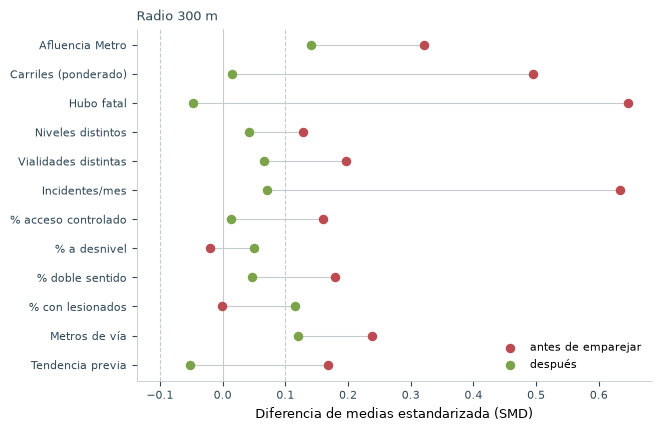

In [14]:
# FIGURA 1 — balance de covariables (love plot)
# la función vive en el pipeline para que las figuras de los cinco radios
# salgan de una sola definición
from pipeline import love_plot

love_plot(balance, titulo=f"Radio {tratadas.radio_m} m")
plt.show()

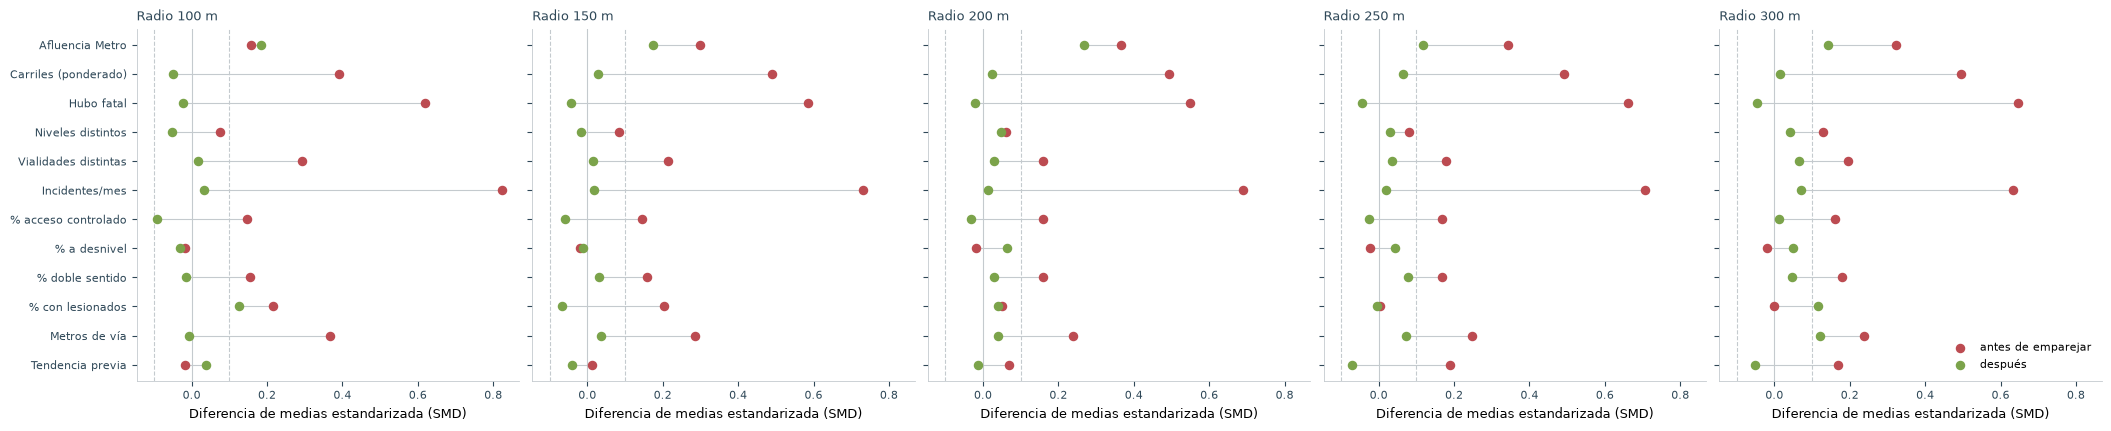

In [15]:
# FIGURA 1b — el mismo balance en los cinco radios
# el orden alfabético de las variables es lo que permite seguir una de panel a
# panel; ordenar por SMD las movería de lugar en cada radio
fig, axes = plt.subplots(1, len(emparejamientos), figsize=(4.2 * len(emparejamientos), 4.2),
                         sharex=True, layout="constrained")

for ax, (radio, e) in zip(axes, emparejamientos.items()):
    love_plot(e.balance, ax=ax, titulo=f"Radio {radio} m")
    if ax is not axes[0]:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    if ax is not axes[-1]:
        ax.get_legend().remove()

plt.show()

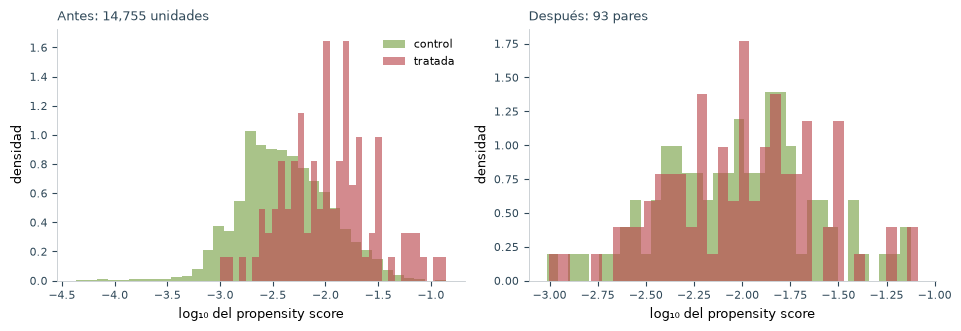

In [16]:
# FIGURA 2 — soporte común antes y después
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), layout="constrained")

for ax, (muestra, titulo) in zip(axes, [
    (datos_ps, f"Antes: {len(datos_ps):,} unidades"),
    (emparejados, f"Después: {len(pares)} pares"),
]):
    for grupo, color, etiqueta in [(0, CONTROL, "control"), (1, TRATADA, "tratada")]:
        serie = np.log10(muestra.loc[muestra.tratado == grupo, "ps"])
        ax.hist(serie, bins=35, density=True, alpha=.65, color=color, label=etiqueta)
    ax.set_xlabel("log₁₀ del propensity score")
    ax.set_ylabel("densidad")
    ax.set_title(titulo, fontsize=9, loc="left", color=TINTA)
    limpiar(ax)

axes[0].legend(frameon=False)
plt.show()

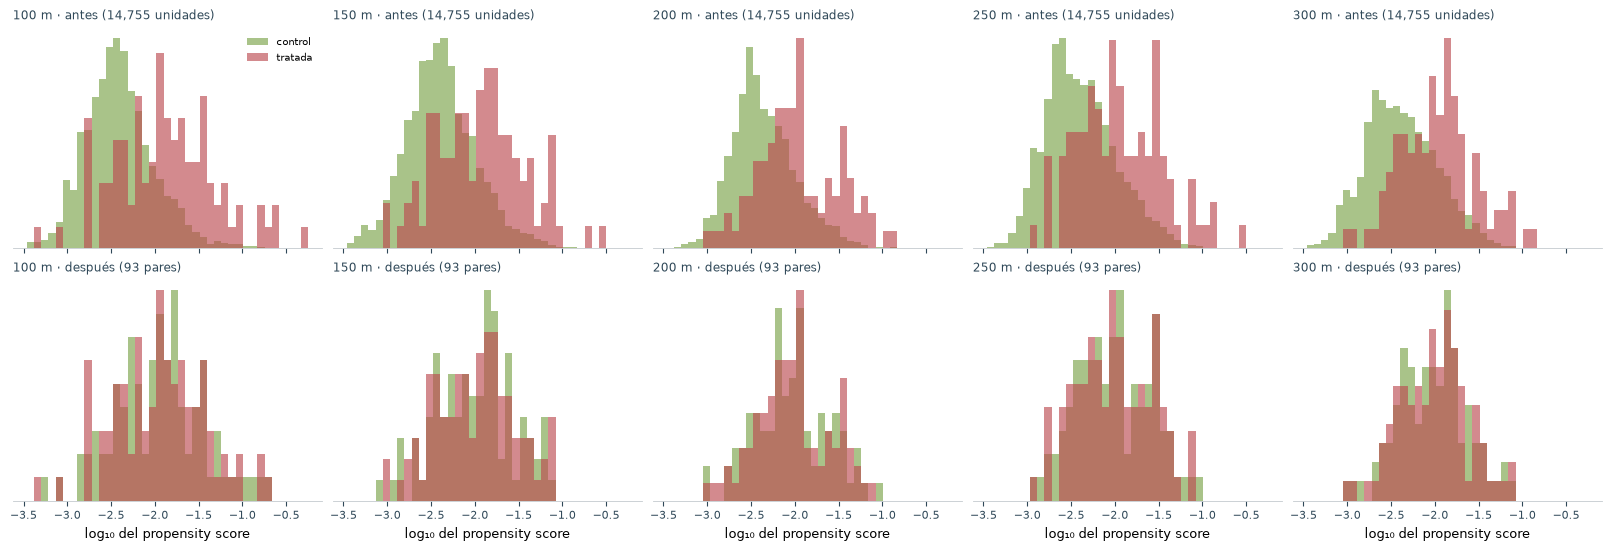

In [17]:
# FIGURA 2b — soporte común en los cinco radios
# el score se reestima en cada radio, así que cada uno tiene su propio soporte
todos_logs = np.concatenate([np.log10(e.datos_ps.ps) for e in emparejamientos.values()])
bordes = np.linspace(np.percentile(todos_logs, .5), todos_logs.max(), 40)

fig, axes = plt.subplots(2, len(emparejamientos), figsize=(3.2 * len(emparejamientos), 5.4),
                         sharex=True, layout="constrained")
for j, (radio, e) in enumerate(emparejamientos.items()):
    for i, (muestra, momento) in enumerate([(e.datos_ps, "antes"), (e.emparejados, "después")]):
        ax = axes[i, j]
        for grupo, color, etiqueta in [(0, CONTROL, "control"), (1, TRATADA, "tratada")]:
            ax.hist(np.log10(muestra.loc[muestra.tratado == grupo, "ps"]), bins=bordes,
                    density=True, alpha=.65, color=color, label=etiqueta)
        n = f"{len(muestra):,} unidades" if momento == "antes" else f"{len(e.pares)} pares"
        ax.set_title(f"{radio} m · {momento} ({n})", fontsize=8.5, loc="left", color=TINTA)
        ax.set_yticks([])
        limpiar(ax)
        ax.spines["left"].set_visible(False)
        if i == 1:
            ax.set_xlabel("log₁₀ del propensity score")

axes[0, 0].legend(frameon=False, fontsize=7.5)
plt.show()

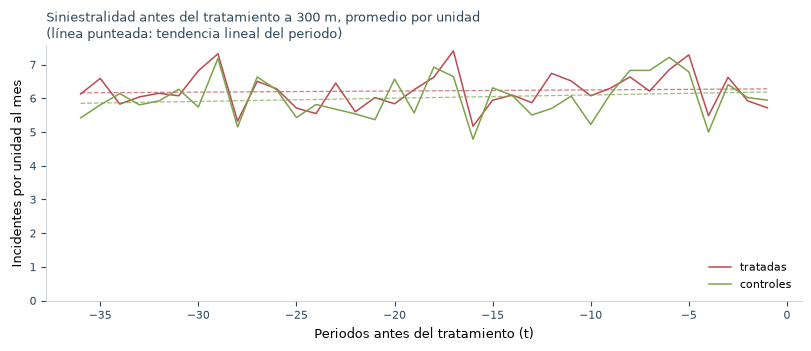

36 periodos, de t = -36 a t = -1
pendiente anual de cada serie previa (incidentes/mes por año):
  tratadas    +0.040
  controles   +0.115
  diferencia  -0.075


In [18]:
# FIGURA 3 — tendencias previas: la evidencia del supuesto de identificación
from pipeline import Panel


def serie_previa(emparejamiento):
    """Incidentes por unidad al mes en los 36 periodos previos, por grupo.

    Mismos periodos que el panel del DiD —del 22 al 22—, no meses de calendario:
    con calendario los extremos quedan con 9 y 21 días de datos y salen bajos.
    """
    tabla = Panel(emparejamiento).tabla
    return (tabla[tabla.t < 0].groupby(["t", "tratado"]).incidentes.mean()
            .unstack().rename(columns={0: "controles", 1: "tratadas"}))


def pendiente_anual(serie_grupo):
    return np.polyfit(serie_grupo.index.to_numpy(), serie_grupo.to_numpy(), 1)[0] * 12


def dibujar_tendencias(ax, serie):
    x = serie.index.to_numpy()
    for columna, color in [("tratadas", TRATADA), ("controles", CONTROL)]:
        ax.plot(x, serie[columna], color=color, lw=1.1, label=columna)
        # tendencia lineal del periodo, para ver si las pendientes son paralelas
        ax.plot(x, np.polyval(np.polyfit(x, serie[columna], 1), x),
                color=color, lw=.9, ls="--", alpha=.7)
    ax.set_ylim(bottom=0)
    limpiar(ax)


serie = serie_previa(emp)
fig, ax = plt.subplots(figsize=(8, 3.4), layout="constrained")
dibujar_tendencias(ax, serie)
ax.set_ylabel("Incidentes por unidad al mes")
ax.set_xlabel("Periodos antes del tratamiento (t)")
ax.set_title(f"Siniestralidad antes del tratamiento a {emp.radio_m} m, promedio por unidad\n"
             "(línea punteada: tendencia lineal del periodo)", fontsize=9, loc="left", color=TINTA)
ax.legend(frameon=False, loc="lower right")
plt.show()

print(f"{len(serie)} periodos, de t = {serie.index.min()} a t = {serie.index.max()}")
print("pendiente anual de cada serie previa (incidentes/mes por año):")
for grupo in ("tratadas", "controles"):
    print(f"  {grupo:<11} {pendiente_anual(serie[grupo]):+.3f}")
print(f"  diferencia  {pendiente_anual(serie.tratadas) - pendiente_anual(serie.controles):+.3f}")

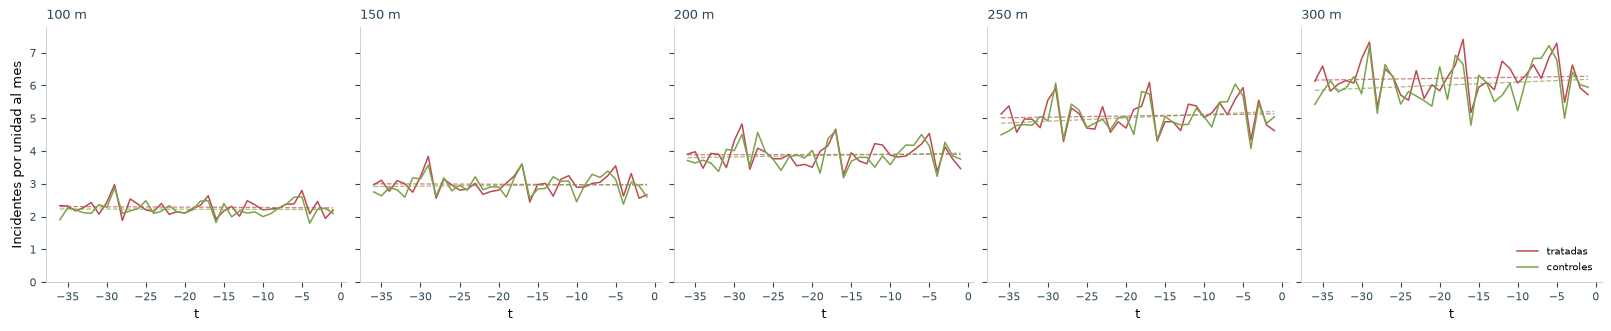

PENDIENTE ANUAL DE LAS SERIES PREVIAS (incidentes/mes por año)


,media control,pendiente tratadas,pendiente controles,diferencia,"diferencia, % del control por año"
radio,,,,,
100,2.223,-0.014,-0.006,-0.008,-0.375
150,2.949,-0.012,0.022,-0.035,-1.174
200,3.866,0.005,0.048,-0.043,-1.121
250,5.027,0.042,0.123,-0.082,-1.625
300,6.019,0.040,0.115,-0.075,-1.253


In [34]:
# FIGURA 3b — tendencias previas en los cinco radios
# en cada radio los controles son otros: el supuesto se verifica columna por columna.
# El eje y es común a los cinco paneles para que se vea cómo sube el nivel con el radio
fig, axes = plt.subplots(1, len(emparejamientos), figsize=(3.2 * len(emparejamientos), 3.2),
                         sharex=True, sharey=True, layout="constrained")
filas = []
for ax, (radio, e) in zip(axes, emparejamientos.items()):
    s = serie_previa(e)
    dibujar_tendencias(ax, s)
    ax.set_title(f"{radio} m", fontsize=9, loc="left", color=TINTA)
    ax.set_xlabel("t")
    pt, pc = pendiente_anual(s.tratadas), pendiente_anual(s.controles)
    filas.append({"radio": radio, "media control": s.controles.mean(),
                  "pendiente tratadas": pt, "pendiente controles": pc,
                  "diferencia": pt - pc,
                  "diferencia, % del control por año": 100 * (pt - pc) / s.controles.mean()})

# el techo común se fija al final: `dibujar_tendencias` pone el piso en cero y eso
# congela el eje compartido en el rango del primer panel
techo = max(serie_previa(e)[["tratadas", "controles"]].to_numpy().max()
            for e in emparejamientos.values())
axes[0].set_ylim(0, techo * 1.05)
axes[0].set_ylabel("Incidentes por unidad al mes")
axes[-1].legend(frameon=False, fontsize=7.5, loc="lower right")
plt.show()

print("PENDIENTE ANUAL DE LAS SERIES PREVIAS (incidentes/mes por año)")
pd.DataFrame(filas).set_index("radio").round(3)

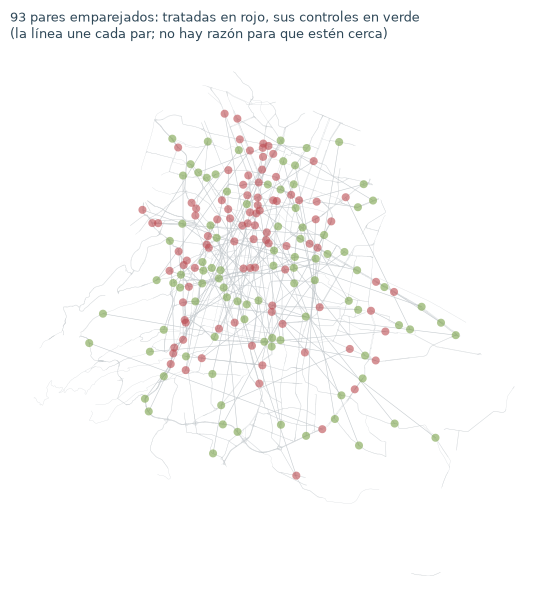

In [20]:
# FIGURA 4 — dónde quedaron los pares
fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")
ax.set_axis_off()

datos.vialidades.plot(ax=ax, linewidth=.15, color=GRIS, zorder=1)

geo_tratadas = tratadas.unidades.set_index("unidad_id").geometry
geo_controles = control.unidades.set_index("unidad_id").geometry
for _, fila in pares.iterrows():
    t_geom = geo_tratadas.loc[int(fila.tratada[1:])].centroid
    c_geom = geo_controles.loc[int(fila.control[1:])].centroid
    ax.plot([t_geom.x, c_geom.x], [t_geom.y, c_geom.y], color=GRIS, lw=.4, zorder=2)

gpd.GeoSeries([geo_controles.loc[int(u[1:])] for u in pares.control], crs=datos.crs).plot(
    ax=ax, facecolor=CONTROL, edgecolor="none", alpha=.6, zorder=3)
gpd.GeoSeries([geo_tratadas.loc[int(u[1:])] for u in pares.tratada], crs=datos.crs).plot(
    ax=ax, facecolor=TRATADA, edgecolor="none", alpha=.6, zorder=4)

ax.set_title(f"{len(pares)} pares emparejados: tratadas en rojo, sus controles en verde\n"
             "(la línea une cada par; no hay razón para que estén cerca)",
             fontsize=9, loc="left", color=TINTA)
plt.show()